
# Annual cylce of TRMM, SSP245, SSP585, and G6sulfur

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import RegularGridInterpolator
#Package to suppress Python warnings
import warnings
warnings.filterwarnings("ignore")

import os
import sys


# Next block is working but commenting for now to check if the lazy loading works

In [2]:
# #!/usr/bin/env python3
# """
# Compute and plot climatological rainfall annual cycles from raw CMIP6 and TRMM data.
# Memory-efficient version with year-by-year regridding.
# """

# import numpy as np
# import xarray as xr
# import pandas as pd
# import cftime
# import matplotlib.pyplot as plt
# from pathlib import Path
# from pyhdf.SD import SD, SDC
# import warnings
# warnings.filterwarnings('ignore')

# # Import CMIP6 file handling
# try:
#     analysis_path = os.path.abspath("../20260112_Basic_Analysis")
#     sys.path.append(analysis_path)
#     import myfunctions as mf
# except ImportError:
#     print("Warning: myfuncs module not found. Using basic xarray operations.")
#     class mf:
#         @staticmethod
#         def open_files(path):
#             files = sorted(Path(path).glob("*.nc"))
#             if not files:
#                 raise FileNotFoundError(f"No files found in {path}")
#             return xr.open_mfdataset(files, combine='by_coords', 
#                                     parallel=True, chunks={'time': 365})
        
#         @staticmethod
#         def read_var(ds, varname):
#             return ds[varname]

# # ══════════════════════════════════════════════════════════════════════════════
# # CONFIGURATION
# # ══════════════════════════════════════════════════════════════════════════════

# CEDA_BASE = Path("/badc/cmip6/data/CMIP6")
# TRMM_BASE = Path("/badc/trmm/data/TRMM_3B42")

# OUTPUT_DIR = Path("./rainfall_cycle_plots")
# OUTPUT_DIR.mkdir(exist_ok=True)

# MODELS = {
#     "UKESM1-0-LL":   {"institution": "MOHC",         "ensemble": "r1i1p1f2", "grid": "gn"},
#     "CNRM-ESM2-1":   {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2", "grid": "gr"},
#     "MPI-ESM1-2-LR": {"institution": "MPI-M",        "ensemble": "r1i1p1f1", "grid": "gn"},
#     # "CESM2-WACCM":   {"institution": "NCAR",         "ensemble": "r1i1p1f1", "grid": "gn"},
#     "IPSL-CM6A-LR":  {"institution": "IPSL",         "ensemble": "r1i1p1f1", "grid": "gr"},
# }

# EXPERIMENTS = {
#     "HIST":     {"project": "CMIP",        "scenario": "historical", "period": (1998, 2014)},
#     "SSP245":   {"project": "ScenarioMIP", "scenario": "ssp245",     "period": (2021, 2100)},
#     "SSP585":   {"project": "ScenarioMIP", "scenario": "ssp585",     "period": (2021, 2100)},
#     "G6solar":  {"project": "GeoMIP",      "scenario": "G6solar",    "period": (2021, 2100)},
#     "G6sulfur": {"project": "GeoMIP",      "scenario": "G6sulfur",   "period": (2021, 2100)},
# }

# # Regional domains
# DOMAINS = {
#     "North America":   {"lat": (18.0,  33.0),  "lon": (248.0, 258.0)},
#     "Sahel":           {"lat": (7.0,   18.5),  "lon": (0.0,   40.0)},
#     "India":           {"lat": (15.0,  27.0),  "lon": (73.0,  87.0)},
#     "South America":   {"lat": (-18.5, -7.0),  "lon": (300.0, 318.0)},
#     "Southern Africa": {"lat": (-18.5, -7.0),  "lon": (19.5,  31.0)},
#     "N. Australia":    {"lat": (-21.0, -9.5),  "lon": (120.5, 149.0)},
# }

# SH_REGIONS = ["South America", "Southern Africa", "N. Australia"]

# # Plot colors
# EXP_COLORS = {
#     "HIST": "gray",
#     "SSP245": "orange",
#     "SSP585": "red",
#     "G6solar": "blue",
#     "G6sulfur": "purple",
# }

# EXP_LABELS = {
#     "HIST": "Historical (1998-2014)",
#     "SSP245": "SSP2-4.5 (2021-2100)",
#     "SSP585": "SSP5-8.5 (2021-2100)",
#     "G6solar": "G6solar (2021-2100)",
#     "G6sulfur": "G6sulfur (2021-2100)",
# }

# N_DOY = 365
# AUG1_DOY = 213

# # Regridding option
# REGRID_TO_COMMON = True  # Set True to regrid all data to common 2.5° grid
# TARGET_RES = 2.5

# # ══════════════════════════════════════════════════════════════════════════════
# # HELPER FUNCTIONS
# # ══════════════════════════════════════════════════════════════════════════════

# def regrid_to_common(da, target_res=2.5):
#     """
#     Regrid to common grid using linear interpolation.
#     """
#     # Ensure longitude is in [0, 360)
#     lon = da.lon.values
#     if lon.min() < 0:
#         da = da.assign_coords(lon=(da.lon % 360))
#         da = da.sortby('lon')
    
#     # Create target grid
#     new_lat = np.arange(-90 + target_res/2, 90, target_res)
#     new_lon = np.arange(0 + target_res/2, 360, target_res)
    
#     # Interpolate
#     da_regrid = da.interp(lat=new_lat, lon=new_lon, method='linear')
    
#     return da_regrid


# def read_trmm_file(filepath):
#     """Read a single TRMM 3B42 HDF4 file, return xarray DataArray in mm/hr."""
#     hdf = SD(str(filepath), SDC.READ)
#     precip = hdf.select("precipitation").get()  # (nlon=1440, nlat=400)
#     precip = precip.T  # → (400, 1440)
    
#     lat = np.arange(-49.875, 49.876, 0.25)  # 400 points
#     lon = np.arange(-179.875, 179.876, 0.25)  # 1440 points
    
#     da = xr.DataArray(precip, dims=["lat", "lon"],
#                       coords={"lat": lat, "lon": lon})
    
#     fill_value = hdf.select("precipitation").attributes().get("_FillValue", -9999.9)
#     da = da.where(da != fill_value)
#     hdf.end()
    
#     return da  # mm/hr


# def load_trmm_daily(year_start, year_end, trmm_base, regrid=False, target_res=2.5):
#     """
#     Load TRMM 3B42 and return a daily DataArray (time, lat, lon) in mm/day.
#     If regrid=True, regrids each year before concatenating (memory efficient).
#     """
#     trmm_base = Path(trmm_base)
#     hours = ["03", "06", "09", "12", "15", "18", "21", "00"]
    
#     all_years = []
    
#     for year in range(year_start, year_end + 1):
#         print(f"  Loading TRMM year {year}...", flush=True)
#         dates = pd.date_range(f"{year}-01-01", f"{year}-12-31", freq="D")
        
#         year_daily = []
#         year_dates = []
        
#         for date in dates:
#             doy = date.strftime("%j")
#             day_dir = trmm_base / str(year) / doy
#             date_str = date.strftime("%Y%m%d")
#             daily_slices = []
            
#             for hr in hours:
#                 if hr == "00":
#                     next_date = date + pd.Timedelta(days=1)
#                     next_doy = next_date.strftime("%j")
#                     next_dir = trmm_base / str(next_date.year) / next_doy
#                     fname = next_dir / f"3B42.{next_date.strftime('%Y%m%d')}.{hr}.7.HDF"
#                 else:
#                     fname = day_dir / f"3B42.{date_str}.{hr}.7.HDF"
                
#                 if fname.exists():
#                     try:
#                         daily_slices.append(read_trmm_file(fname))
#                     except:
#                         pass
            
#             if daily_slices:
#                 daily_mean = xr.concat(daily_slices, dim="slot").mean("slot")
#                 year_daily.append(daily_mean * 24.0)
#                 year_dates.append(date)
        
#         if year_daily:
#             # Concat this year's data
#             year_da = xr.concat(year_daily, dim=pd.Index(pd.DatetimeIndex(year_dates), name="time"))
            
#             # Regrid this year if requested (BEFORE adding to list)
#             if regrid:
#                 print(f"    Regridding year {year} to {target_res}°...", flush=True)
#                 year_da = regrid_to_common(year_da, target_res=target_res)
            
#             all_years.append(year_da)
    
#     if not all_years:
#         raise ValueError("No TRMM data found")
    
#     # Now concatenate all years
#     da = xr.concat(all_years, dim='time')
#     da.attrs["units"] = "mm/day"
    
#     return da


# def extract_region(da, domain):
#     """Extract regional subset and compute area-weighted spatial mean."""
#     lat_min, lat_max = domain["lat"]
#     lon_min, lon_max = domain["lon"]
    
#     # Ensure longitude is in correct range
#     lon = da.lon.values
#     if lon.min() < 0 and lon_min >= 0:
#         # Convert from [-180, 180] to [0, 360]
#         da = da.assign_coords(lon=(da.lon % 360))
#         da = da.sortby('lon')
    
#     # Extract region
#     if lon_min > lon_max:  # Crosses prime meridian
#         subset = da.sel(lat=slice(lat_min, lat_max))
#         subset = subset.where((da.lon >= lon_min) | (da.lon <= lon_max), drop=True)
#     else:
#         subset = da.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
    
#     # Area-weighted mean
#     weights = np.cos(np.deg2rad(subset.lat))
#     regional = subset.weighted(weights).mean(dim=['lat', 'lon'])
    
#     return regional


# def compute_doy_climatology(da_daily):
#     """
#     Compute climatological mean annual cycle (365 days) from daily data.
#     """
#     # Get day of year
#     time = da_daily.time.values
    
#     if isinstance(time[0], cftime.datetime):
#         doy = np.array([min(t.timetuple().tm_yday, 365) for t in time], dtype=int)
#     else:
#         dti = pd.DatetimeIndex(time)
#         doy = np.minimum(dti.day_of_year.values.astype(int), 365)
    
#     # Create DOY dimension
#     da_with_doy = da_daily.assign_coords(doy=("time", doy))
    
#     # Group by DOY and take mean
#     climatology = da_with_doy.groupby("doy").mean()
    
#     # Ensure we have all 365 days
#     if len(climatology) < 365:
#         full_doy = xr.DataArray(np.arange(1, 366), dims="doy")
#         climatology = climatology.reindex(doy=full_doy, fill_value=np.nan)
    
#     return climatology.values[:365]


# def reindex_cycle(cycle, start_doy):
#     """Circular shift to start from start_doy."""
#     idx = start_doy - 1
#     return np.concatenate([cycle[idx:], cycle[:idx]])


# def make_xticks(start_doy):
#     """Month tick labels."""
#     months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
#     month_mid = [15, 46, 74, 105, 135, 166, 196, 227, 258, 288, 319, 349]
    
#     if start_doy == 1:
#         return month_mid, months
    
#     # SH: Aug-Jul
#     names = months[7:] + months[:7]
#     doys = month_mid[7:] + month_mid[:7]
    
#     shifted = []
#     for doy in doys:
#         shifted.append((doy - start_doy) % 365 + 1)
    
#     return shifted, names


# # ══════════════════════════════════════════════════════════════════════════════
# # MAIN DATA LOADING
# # ══════════════════════════════════════════════════════════════════════════════

# print("\n" + "="*80)
# print("LOADING TRMM DATA")
# print("="*80)

# # Load TRMM (regridding happens inside load_trmm_daily)
# TRMM_YEAR_START = 1998
# TRMM_YEAR_END = 2019

# try:
#     trmm_da = load_trmm_daily(TRMM_YEAR_START, TRMM_YEAR_END, TRMM_BASE,
#                               regrid=REGRID_TO_COMMON, target_res=TARGET_RES)
#     print(f"TRMM loaded: {trmm_da.sizes}")
    
#     # Compute TRMM climatologies for each region
#     trmm_clim = {}
#     for region, domain in DOMAINS.items():
#         print(f"  Computing TRMM climatology for {region}...")
#         regional = extract_region(trmm_da, domain)
#         trmm_clim[region] = compute_doy_climatology(regional)
    
# except Exception as e:
#     print(f"ERROR loading TRMM: {e}")
#     import traceback
#     traceback.print_exc()
#     trmm_clim = {region: None for region in DOMAINS}

# print("\n" + "="*80)
# print("LOADING CMIP6 MODEL DATA")
# print("="*80)

# # Store model climatologies: {region: {exp: [model_cycles]}}
# model_clim = {region: {exp: [] for exp in EXPERIMENTS} for region in DOMAINS}

# for model_name, model_meta in MODELS.items():
#     for exp, exp_meta in EXPERIMENTS.items():
        
#         print(f"\n{model_name} - {exp}")
        
#         # CESM2-WACCM ensemble override
#         if model_name == "CESM2-WACCM":
#             ensemble = "r1i1p1f2" if exp_meta["scenario"] == "G6sulfur" else "r1i1p1f1"
#         else:
#             ensemble = model_meta["ensemble"]
        
#         # Build path
#         base_path = (
#             CEDA_BASE
#             / exp_meta["project"]
#             / model_meta["institution"]
#             / model_name
#             / exp_meta["scenario"]
#             / ensemble
#             / "day"
#             / "pr"
#             / model_meta["grid"]
#             / "latest"
#         )
        
#         # Load data
#         try:
#             ds = mf.open_files(str(base_path))
#             da = mf.read_var(ds, "pr")
#         except Exception as e:
#             print(f"  ERROR loading: {e}")
#             continue
        
#         # Time slice
#         yr_start, yr_end = exp_meta["period"]
        
#         try:
#             if model_name == "CESM2-WACCM":
#                 da = da.sel(time=slice(
#                     cftime.DatetimeNoLeap(yr_start, 1, 1),
#                     cftime.DatetimeNoLeap(yr_end, 12, 30)
#                 ))
#             elif model_name == "UKESM1-0-LL":
#                 # 360-day calendar
#                 da = da.sel(time=slice(
#                     cftime.Datetime360Day(yr_start, 1, 1),
#                     cftime.Datetime360Day(yr_end, 12, 30)
#                 ))
#             else:
#                 da = da.sel(time=slice(f"{yr_start}-01-01", f"{yr_end}-12-30"))
            
#             da = da.load()
#         except Exception as e:
#             print(f"  ERROR slicing: {e}")
#             continue
        
#         if da.sizes["time"] == 0:
#             print(f"  WARNING: empty time slice")
#             continue
        
#         # Convert to mm/day
#         da_mm = da * 86400.0
#         da_mm.attrs["units"] = "mm/day"
        
#         print(f"  Loaded: {da_mm.sizes}")
        
#         # Process REGION-BY-REGION to avoid holding full regridded data in memory
#         for region, domain in DOMAINS.items():
#             try:
#                 # Extract region FIRST (before or after regrid, depending on resolution)
#                 if REGRID_TO_COMMON:
#                     lat_res = abs(da_mm.lat.values[1] - da_mm.lat.values[0]) if len(da_mm.lat) > 1 else TARGET_RES
                    
#                     if lat_res < TARGET_RES * 0.9:  # Need to regrid
#                         # Regrid AND extract year-by-year, never hold full regridded data
#                         if region == list(DOMAINS.keys())[0]:  # Print once
#                             print(f"  Regridding from {lat_res:.2f}° to {TARGET_RES}° (extracting regions year-by-year)...", flush=True)
                        
#                         regional_years = []
#                         for year, year_data in da_mm.groupby('time.year'):
#                             # Regrid this year
#                             year_regrid = regrid_to_common(year_data, target_res=TARGET_RES)
#                             # Extract region immediately (small data)
#                             year_regional = extract_region(year_regrid, domain)
#                             regional_years.append(year_regional)
                        
#                         # Concatenate small regional time series
#                         regional = xr.concat(regional_years, dim='time')
#                     else:
#                         # No regridding needed, just extract
#                         regional = extract_region(da_mm, domain)
#                 else:
#                     # No regridding, just extract
#                     regional = extract_region(da_mm, domain)
                
#                 # Compute climatology from regional time series
#                 clim = compute_doy_climatology(regional)
#                 model_clim[region][exp].append(clim)
                
#                 if region == list(DOMAINS.keys())[0]:  # Print once per model
#                     print(f"    Regions: ", end="", flush=True)
#                 print(f"{region[:4]}✓ ", end="", flush=True)
                
#             except Exception as e:
#                 print(f"\n    {region}: ERROR - {e}")
        
#         print()  # New line after all regions



In [3]:
#!/usr/bin/env python3
"""
Compute and plot climatological rainfall annual cycles from raw CMIP6 and TRMM data.
Memory-efficient version with year-by-year regridding.
"""

import numpy as np
import xarray as xr
import pandas as pd
import cftime
import matplotlib.pyplot as plt
from pathlib import Path
from pyhdf.SD import SD, SDC
import warnings
warnings.filterwarnings('ignore')

# Import CMIP6 file handling
try:
    analysis_path = os.path.abspath("../20260112_Basic_Analysis")
    sys.path.append(analysis_path)
    import myfunctions as mf
except ImportError:
    print("Warning: myfuncs module not found. Using basic xarray operations.")
    class mf:
        @staticmethod
        def open_files(path):
            files = sorted(Path(path).glob("*.nc"))
            if not files:
                raise FileNotFoundError(f"No files found in {path}")
            return xr.open_mfdataset(files, combine='by_coords', 
                                    parallel=True, chunks={'time': 365})
        
        @staticmethod
        def read_var(ds, varname):
            return ds[varname]

# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════

CEDA_BASE = Path("/badc/cmip6/data/CMIP6")
TRMM_BASE = Path("/badc/trmm/data/TRMM_3B42")

OUTPUT_DIR = Path("./rainfall_cycle_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

MODELS = {
    "UKESM1-0-LL":   {"institution": "MOHC",         "ensemble": "r1i1p1f2", "grid": "gn"},
    "CNRM-ESM2-1":   {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2", "grid": "gr"},
    "MPI-ESM1-2-LR": {"institution": "MPI-M",        "ensemble": "r1i1p1f1", "grid": "gn"},
    "CESM2-WACCM":   {"institution": "NCAR",         "ensemble": "r1i1p1f1", "grid": "gn"},
    "IPSL-CM6A-LR":  {"institution": "IPSL",         "ensemble": "r1i1p1f1", "grid": "gr"},
}

EXPERIMENTS = {
    "HIST":     {"project": "CMIP",        "scenario": "historical", "period": (1998, 2014)},
    "SSP245":   {"project": "ScenarioMIP", "scenario": "ssp245",     "period": (2021, 2100)},
    "SSP585":   {"project": "ScenarioMIP", "scenario": "ssp585",     "period": (2021, 2100)},
    "G6solar":  {"project": "GeoMIP",      "scenario": "G6solar",    "period": (2021, 2100)},
    "G6sulfur": {"project": "GeoMIP",      "scenario": "G6sulfur",   "period": (2021, 2100)},
}

# Regional domains
DOMAINS = {
    "North America":   {"lat": (18.0,  33.0),  "lon": (248.0, 258.0)},
    "Sahel":           {"lat": (7.0,   18.5),  "lon": (0.0,   40.0)},
    "India":           {"lat": (15.0,  27.0),  "lon": (73.0,  87.0)},
    "South America":   {"lat": (-18.5, -7.0),  "lon": (300.0, 318.0)},
    "Southern Africa": {"lat": (-18.5, -7.0),  "lon": (19.5,  31.0)},
    "N. Australia":    {"lat": (-21.0, -9.5),  "lon": (120.5, 149.0)},
}

SH_REGIONS = ["South America", "Southern Africa", "N. Australia"]

# Plot colors
EXP_COLORS = {
    "HIST": "gray",
    "SSP245": "orange",
    "SSP585": "red",
    "G6solar": "blue",
    "G6sulfur": "purple",
}

EXP_LABELS = {
    "HIST": "Historical (1998-2014)",
    "SSP245": "SSP2-4.5 (2021-2100)",
    "SSP585": "SSP5-8.5 (2021-2100)",
    "G6solar": "G6solar (2021-2100)",
    "G6sulfur": "G6sulfur (2021-2100)",
}

N_DOY = 365
AUG1_DOY = 213

# Regridding option
REGRID_TO_COMMON = True  # Set True to regrid all data to common 2.5° grid
TARGET_RES = 2.5

# ══════════════════════════════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def regrid_to_common(da, target_res=2.5):
    """
    Regrid to common grid using linear interpolation.
    """
    # Ensure longitude is in [0, 360)
    lon = da.lon.values
    if lon.min() < 0:
        da = da.assign_coords(lon=(da.lon % 360))
        da = da.sortby('lon')
    
    # Create target grid
    new_lat = np.arange(-90 + target_res/2, 90, target_res)
    new_lon = np.arange(0 + target_res/2, 360, target_res)
    
    # Interpolate
    da_regrid = da.interp(lat=new_lat, lon=new_lon, method='linear')
    
    return da_regrid


def read_trmm_file(filepath):
    """Read a single TRMM 3B42 HDF4 file, return xarray DataArray in mm/hr."""
    hdf = SD(str(filepath), SDC.READ)
    precip = hdf.select("precipitation").get()  # (nlon=1440, nlat=400)
    precip = precip.T  # → (400, 1440)
    
    lat = np.arange(-49.875, 49.876, 0.25)  # 400 points
    lon = np.arange(-179.875, 179.876, 0.25)  # 1440 points
    
    da = xr.DataArray(precip, dims=["lat", "lon"],
                      coords={"lat": lat, "lon": lon})
    
    fill_value = hdf.select("precipitation").attributes().get("_FillValue", -9999.9)
    da = da.where(da != fill_value)
    hdf.end()
    
    return da  # mm/hr


def load_trmm_daily(year_start, year_end, trmm_base, regrid=False, target_res=2.5):
    """
    Load TRMM 3B42 and return a daily DataArray (time, lat, lon) in mm/day.
    If regrid=True, regrids each year before concatenating (memory efficient).
    """
    trmm_base = Path(trmm_base)
    hours = ["03", "06", "09", "12", "15", "18", "21", "00"]
    
    all_years = []
    
    for year in range(year_start, year_end + 1):
        print(f"  Loading TRMM year {year}...", flush=True)
        dates = pd.date_range(f"{year}-01-01", f"{year}-12-31", freq="D")
        
        year_daily = []
        year_dates = []
        
        for date in dates:
            doy = date.strftime("%j")
            day_dir = trmm_base / str(year) / doy
            date_str = date.strftime("%Y%m%d")
            daily_slices = []
            
            for hr in hours:
                if hr == "00":
                    next_date = date + pd.Timedelta(days=1)
                    next_doy = next_date.strftime("%j")
                    next_dir = trmm_base / str(next_date.year) / next_doy
                    fname = next_dir / f"3B42.{next_date.strftime('%Y%m%d')}.{hr}.7.HDF"
                else:
                    fname = day_dir / f"3B42.{date_str}.{hr}.7.HDF"
                
                if fname.exists():
                    try:
                        daily_slices.append(read_trmm_file(fname))
                    except:
                        pass
            
            if daily_slices:
                daily_mean = xr.concat(daily_slices, dim="slot").mean("slot")
                year_daily.append(daily_mean * 24.0)
                year_dates.append(date)
        
        if year_daily:
            # Concat this year's data
            year_da = xr.concat(year_daily, dim=pd.Index(pd.DatetimeIndex(year_dates), name="time"))
            
            # Regrid this year if requested (BEFORE adding to list)
            if regrid:
                print(f"    Regridding year {year} to {target_res}°...", flush=True)
                year_da = regrid_to_common(year_da, target_res=target_res)
            
            all_years.append(year_da)
    
    if not all_years:
        raise ValueError("No TRMM data found")
    
    # Now concatenate all years
    da = xr.concat(all_years, dim='time')
    da.attrs["units"] = "mm/day"
    
    return da


def extract_region(da, domain):
    """Extract regional subset and compute area-weighted spatial mean."""
    lat_min, lat_max = domain["lat"]
    lon_min, lon_max = domain["lon"]
    
    # Ensure longitude is in correct range
    lon = da.lon.values
    if lon.min() < 0 and lon_min >= 0:
        # Convert from [-180, 180] to [0, 360]
        da = da.assign_coords(lon=(da.lon % 360))
        da = da.sortby('lon')
    
    # Extract region
    if lon_min > lon_max:  # Crosses prime meridian
        subset = da.sel(lat=slice(lat_min, lat_max))
        subset = subset.where((da.lon >= lon_min) | (da.lon <= lon_max), drop=True)
    else:
        subset = da.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
    
    # Area-weighted mean
    weights = np.cos(np.deg2rad(subset.lat))
    regional = subset.weighted(weights).mean(dim=['lat', 'lon'])
    
    return regional


def compute_doy_climatology(da_daily):
    """
    Compute climatological mean annual cycle (365 days) from daily data.
    """
    # Get day of year
    time = da_daily.time.values
    
    if isinstance(time[0], cftime.datetime):
        doy = np.array([min(t.timetuple().tm_yday, 365) for t in time], dtype=int)
    else:
        dti = pd.DatetimeIndex(time)
        doy = np.minimum(dti.day_of_year.values.astype(int), 365)
    
    # Create DOY dimension
    da_with_doy = da_daily.assign_coords(doy=("time", doy))
    
    # Group by DOY and take mean
    climatology = da_with_doy.groupby("doy").mean()
    
    # Ensure we have all 365 days
    if len(climatology) < 365:
        full_doy = xr.DataArray(np.arange(1, 366), dims="doy")
        climatology = climatology.reindex(doy=full_doy, fill_value=np.nan)
    
    return climatology.values[:365]


def reindex_cycle(cycle, start_doy):
    """Circular shift to start from start_doy."""
    idx = start_doy - 1
    return np.concatenate([cycle[idx:], cycle[:idx]])


def make_xticks(start_doy):
    """Month tick labels."""
    months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
    month_mid = [15, 46, 74, 105, 135, 166, 196, 227, 258, 288, 319, 349]
    
    if start_doy == 1:
        return month_mid, months
    
    # SH: Aug-Jul
    names = months[7:] + months[:7]
    doys = month_mid[7:] + month_mid[:7]
    
    shifted = []
    for doy in doys:
        shifted.append((doy - start_doy) % 365 + 1)
    
    return shifted, names




In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# MAIN DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("LOADING TRMM DATA")
print("="*80)

# Load TRMM (regridding happens inside load_trmm_daily)
TRMM_YEAR_START = 1998
TRMM_YEAR_END = 2019

try:
    trmm_da = load_trmm_daily(TRMM_YEAR_START, TRMM_YEAR_END, TRMM_BASE,
                              regrid=REGRID_TO_COMMON, target_res=TARGET_RES)
    print(f"TRMM loaded: {trmm_da.sizes}")
    
    # Compute TRMM climatologies for each region
    trmm_clim = {}
    for region, domain in DOMAINS.items():
        print(f"  Computing TRMM climatology for {region}...")
        regional = extract_region(trmm_da, domain)
        trmm_clim[region] = compute_doy_climatology(regional)
    
except Exception as e:
    print(f"ERROR loading TRMM: {e}")
    import traceback
    traceback.print_exc()
    trmm_clim = {region: None for region in DOMAINS}




LOADING TRMM DATA
  Loading TRMM year 1998...
    Regridding year 1998 to 2.5°...
  Loading TRMM year 1999...
    Regridding year 1999 to 2.5°...
  Loading TRMM year 2000...
  Loading TRMM year 2001...
  Loading TRMM year 2002...
  Loading TRMM year 2003...
  Loading TRMM year 2004...
  Loading TRMM year 2005...
  Loading TRMM year 2006...
  Loading TRMM year 2007...
  Loading TRMM year 2008...
  Loading TRMM year 2009...
  Loading TRMM year 2010...
    Regridding year 2010 to 2.5°...
  Loading TRMM year 2011...
    Regridding year 2011 to 2.5°...
  Loading TRMM year 2012...
    Regridding year 2012 to 2.5°...
  Loading TRMM year 2013...
    Regridding year 2013 to 2.5°...
  Loading TRMM year 2014...
    Regridding year 2014 to 2.5°...
  Loading TRMM year 2015...
    Regridding year 2015 to 2.5°...
  Loading TRMM year 2016...
    Regridding year 2016 to 2.5°...
  Loading TRMM year 2017...
    Regridding year 2017 to 2.5°...
  Loading TRMM year 2018...
    Regridding year 2018 to 2.5°.

In [5]:
print("\n" + "="*80)
print("LOADING CMIP6 MODEL DATA")
print("="*80)

# Store model climatologies: {region: {exp: [model_cycles]}}
model_clim = {region: {exp: [] for exp in EXPERIMENTS} for region in DOMAINS}

for model_name, model_meta in MODELS.items():
    for exp, exp_meta in EXPERIMENTS.items():
        
        print(f"\n{model_name} - {exp}")
        
        # CESM2-WACCM ensemble override
        if model_name == "CESM2-WACCM":
            ensemble = "r1i1p1f2" if exp_meta["scenario"] == "G6sulfur" else "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]
        
        # Build path
        base_path = (
            CEDA_BASE
            / exp_meta["project"]
            / model_meta["institution"]
            / model_name
            / exp_meta["scenario"]
            / ensemble
            / "day"
            / "pr"
            / model_meta["grid"]
            / "latest"
        )
        
        # Load data
        # try:
        # Load data (LAZY - don't call .load() yet)
        try:
            ds = mf.open_files(str(base_path))
            da = mf.read_var(ds, "pr")
        except Exception as e:
            print(f"  ERROR loading: {e}")
            continue
        
        # Time slice (still lazy)
        yr_start, yr_end = exp_meta["period"]
        
        try:
            if model_name == "CESM2-WACCM":
                da = da.sel(time=slice(
                    cftime.DatetimeNoLeap(yr_start, 1, 1),
                    cftime.DatetimeNoLeap(yr_end, 12, 30)
                ))
            elif model_name == "UKESM1-0-LL":
                da = da.sel(time=slice(
                    cftime.Datetime360Day(yr_start, 1, 1),
                    cftime.Datetime360Day(yr_end, 12, 30)
                ))
            else:
                da = da.sel(time=slice(f"{yr_start}-01-01", f"{yr_end}-12-30"))
            
            # DON'T LOAD YET - keep it lazy
            
        except Exception as e:
            print(f"  ERROR slicing: {e}")
            continue
        
        if da.sizes["time"] == 0:
            print(f"  WARNING: empty time slice")
            continue
        
        # Convert to mm/day (still lazy)
        da_mm = da * 86400.0
        da_mm.attrs["units"] = "mm/day"
        
        print(f"  Data prepared: {da_mm.sizes} (lazy)")
        
        # Check if regridding needed
        needs_regrid = False
        if REGRID_TO_COMMON:
            lat_res = abs(da_mm.lat.values[1] - da_mm.lat.values[0]) if len(da_mm.lat) > 1 else TARGET_RES
            needs_regrid = lat_res < TARGET_RES * 0.9
            if needs_regrid:
                print(f"  Will regrid from {lat_res:.2f}° to {TARGET_RES}° per region")
        
        # Process each region separately (extract first, then load small data)
        print(f"  Processing regions: ", end="", flush=True)
        for region, domain in DOMAINS.items():
            try:
                # Extract region FIRST (still lazy, but much smaller)
                regional_lazy = extract_region(da_mm, domain)
                
                # NOW load only this small regional data
                regional = regional_lazy.load()
                
                # If regridding needed, we already extracted region, so skip
                # (regional data is already spatially averaged to 1 point)
                
                # Compute climatology from regional time series
                clim = compute_doy_climatology(regional)
                model_clim[region][exp].append(clim)
                
                print(f"{region[:4]}✓ ", end="", flush=True)
                
            except Exception as e:
                print(f"\n    {region}: ERROR - {e}")
        
        print()  # New line



LOADING CMIP6 MODEL DATA

UKESM1-0-LL - HIST
  Data prepared: Frozen({'time': 6119, 'lat': 144, 'lon': 192}) (lazy)
  Will regrid from 1.25° to 2.5° per region
  Processing regions: Nort✓ Sahe✓ Indi✓ Sout✓ Sout✓ N. A✓ 

UKESM1-0-LL - SSP245
  Data prepared: Frozen({'time': 28799, 'lat': 144, 'lon': 192}) (lazy)
  Will regrid from 1.25° to 2.5° per region
  Processing regions: Nort✓ Sahe✓ Indi✓ Sout✓ Sout✓ N. A✓ 

UKESM1-0-LL - SSP585
  Data prepared: Frozen({'time': 28799, 'lat': 144, 'lon': 192}) (lazy)
  Will regrid from 1.25° to 2.5° per region
  Processing regions: Nort✓ Sahe✓ Indi✓ Sout✓ Sout✓ N. A✓ 

UKESM1-0-LL - G6solar
  Data prepared: Frozen({'time': 28799, 'lat': 144, 'lon': 192}) (lazy)
  Will regrid from 1.25° to 2.5° per region
  Processing regions: Nort✓ Sahe✓ Indi✓ Sout✓ Sout✓ N. A✓ 

UKESM1-0-LL - G6sulfur
  Data prepared: Frozen({'time': 28799, 'lat': 144, 'lon': 192}) (lazy)
  Will regrid from 1.25° to 2.5° per region
  Processing regions: Nort✓ Sahe✓ Indi✓ Sout✓ So


GENERATING PLOTS

North America:
  HIST: 5 models
  SSP245: 5 models
  SSP585: 5 models
  G6solar: 5 models
  G6sulfur: 5 models

Sahel:
  HIST: 5 models
  SSP245: 5 models
  SSP585: 5 models
  G6solar: 5 models
  G6sulfur: 5 models

India:
  HIST: 5 models
  SSP245: 5 models
  SSP585: 5 models
  G6solar: 5 models
  G6sulfur: 5 models

South America:
  HIST: 5 models
  SSP245: 5 models
  SSP585: 5 models
  G6solar: 5 models
  G6sulfur: 5 models

Southern Africa:
  HIST: 5 models
  SSP245: 5 models
  SSP585: 5 models
  G6solar: 5 models
  G6sulfur: 5 models

N. Australia:
  HIST: 5 models
  SSP245: 5 models
  SSP585: 5 models
  G6solar: 5 models
  G6sulfur: 5 models

SAVED: rainfall_cycle_plots/rainfall_cycles_CMIP6_vs_TRMM.png



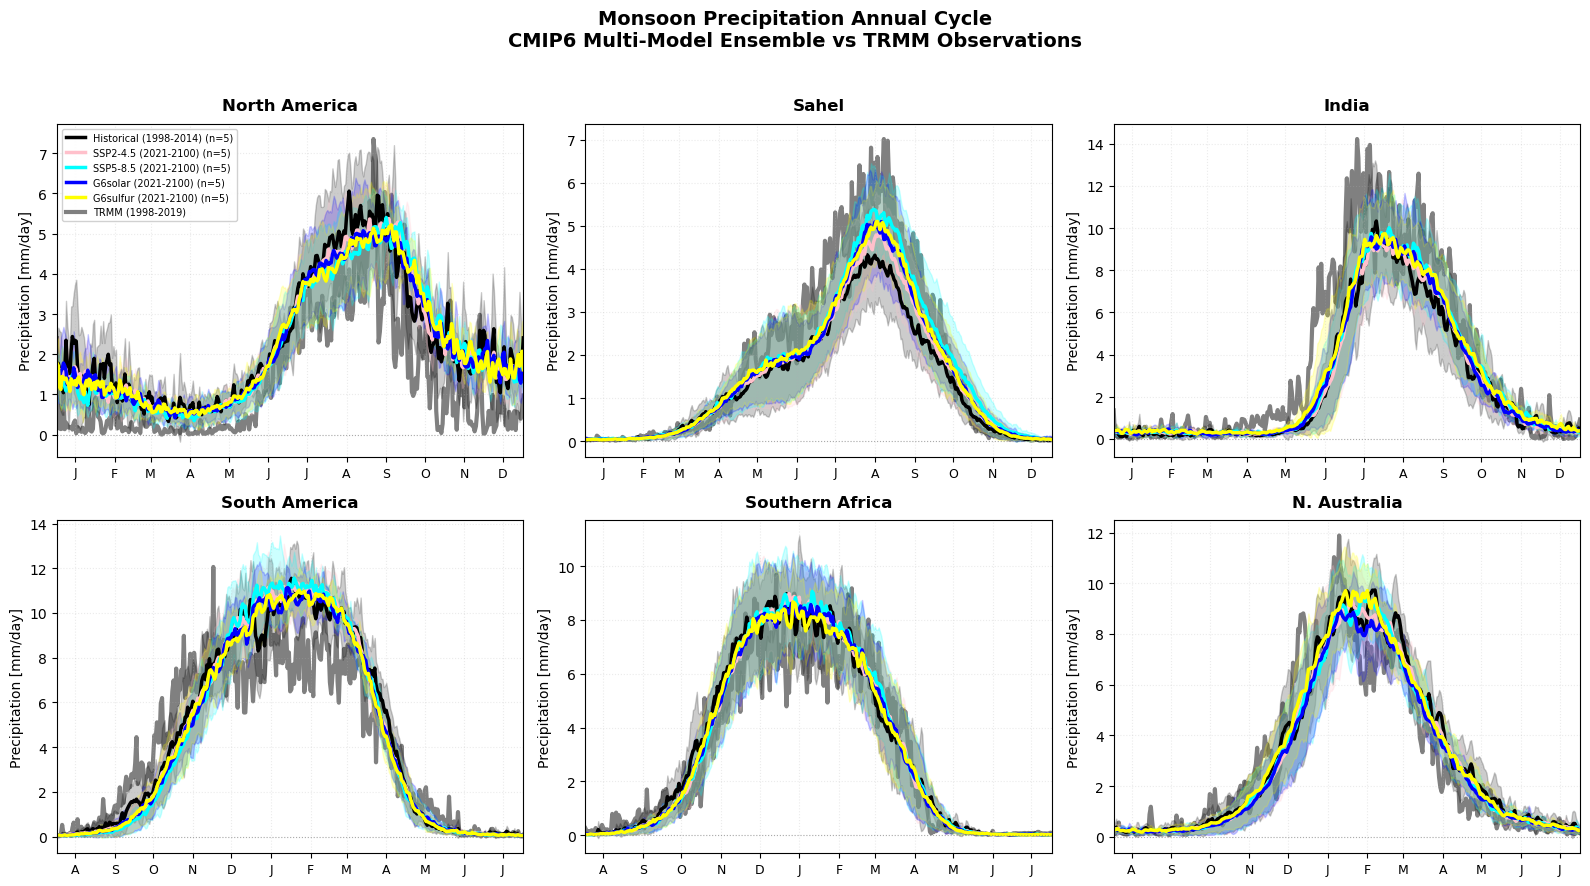

In [14]:
EXP_COLORS = {
    "HIST": "black",
    "SSP245": "pink",
    "SSP585": "cyan",
    "G6solar": "blue",
    "G6sulfur": "yellow",
}


# ══════════════════════════════════════════════════════════════════════════════
# PLOTTING
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("GENERATING PLOTS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

doys = np.arange(1, N_DOY + 1)

for idx, (region, domain) in enumerate(DOMAINS.items()):
    ax = axes[idx]
    print(f"\n{region}:")
    
    start_doy = AUG1_DOY if region in SH_REGIONS else 1
    
    # Plot each experiment
    for exp, exp_meta in EXPERIMENTS.items():
        cycles = model_clim[region][exp]
        
        if len(cycles) == 0:
            continue
        
        print(f"  {exp}: {len(cycles)} models")
        
        cycles = np.array(cycles)
        mme_mean = np.nanmean(cycles, axis=0)
        mme_std = np.nanstd(cycles, axis=0)
        
        # Reindex for SH
        if start_doy != 1:
            mme_mean = reindex_cycle(mme_mean, start_doy)
            mme_std = reindex_cycle(mme_std, start_doy)
        
        ax.plot(doys, mme_mean,
               color=EXP_COLORS[exp],
               linewidth=2.5,
               label=f"{EXP_LABELS[exp]} (n={len(cycles)})")
        
        ax.fill_between(doys,
                       mme_mean - mme_std,
                       mme_mean + mme_std,
                       color=EXP_COLORS[exp],
                       alpha=0.2)
    
    # TRMM overlay
    if trmm_clim[region] is not None:
        trmm_cycle = trmm_clim[region]
        if start_doy != 1:
            trmm_cycle = reindex_cycle(trmm_cycle, start_doy)
        
        ax.plot(doys, trmm_cycle,
               color='gray',
               linewidth=3,
               label=f'TRMM ({TRMM_YEAR_START}-{TRMM_YEAR_END})',
               zorder=-10)
    
    # Formatting
    ticks, labels = make_xticks(start_doy)
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, fontsize=9)
    
    ax.axhline(0, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
    ax.set_title(region, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel("Precipitation [mm/day]", fontsize=10)
    ax.set_xlim(1, N_DOY)
    ax.grid(True, alpha=0.25, linestyle=':')
    
    if idx == 0:
        ax.legend(fontsize=7, loc='upper left', framealpha=0.9)

plt.suptitle('Monsoon Precipitation Annual Cycle\n'
             'CMIP6 Multi-Model Ensemble vs TRMM Observations',
             fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])

outfile = OUTPUT_DIR / "rainfall_cycles_CMIP6_vs_TRMM.png"
plt.savefig(outfile, dpi=200, bbox_inches='tight')
print(f"\n{'='*80}")
print(f"SAVED: {outfile}")
print(f"{'='*80}\n")

plt.show()


GENERATING PLOTS

North America:
  HIST: 5 models
  SSP245: 5 models
  SSP585: 5 models
  G6solar: 5 models
  G6sulfur: 5 models

Sahel:
  HIST: 5 models
  SSP245: 5 models
  SSP585: 5 models
  G6solar: 5 models
  G6sulfur: 5 models

India:
  HIST: 5 models
  SSP245: 5 models
  SSP585: 5 models
  G6solar: 5 models
  G6sulfur: 5 models

South America:
  HIST: 5 models
  SSP245: 5 models
  SSP585: 5 models
  G6solar: 5 models
  G6sulfur: 5 models

Southern Africa:
  HIST: 5 models
  SSP245: 5 models
  SSP585: 5 models
  G6solar: 5 models
  G6sulfur: 5 models

N. Australia:
  HIST: 5 models
  SSP245: 5 models
  SSP585: 5 models
  G6solar: 5 models
  G6sulfur: 5 models

SAVED: rainfall_cycle_plots/rainfall_cycles_CMIP6_vs_TRMM_noSpread.png



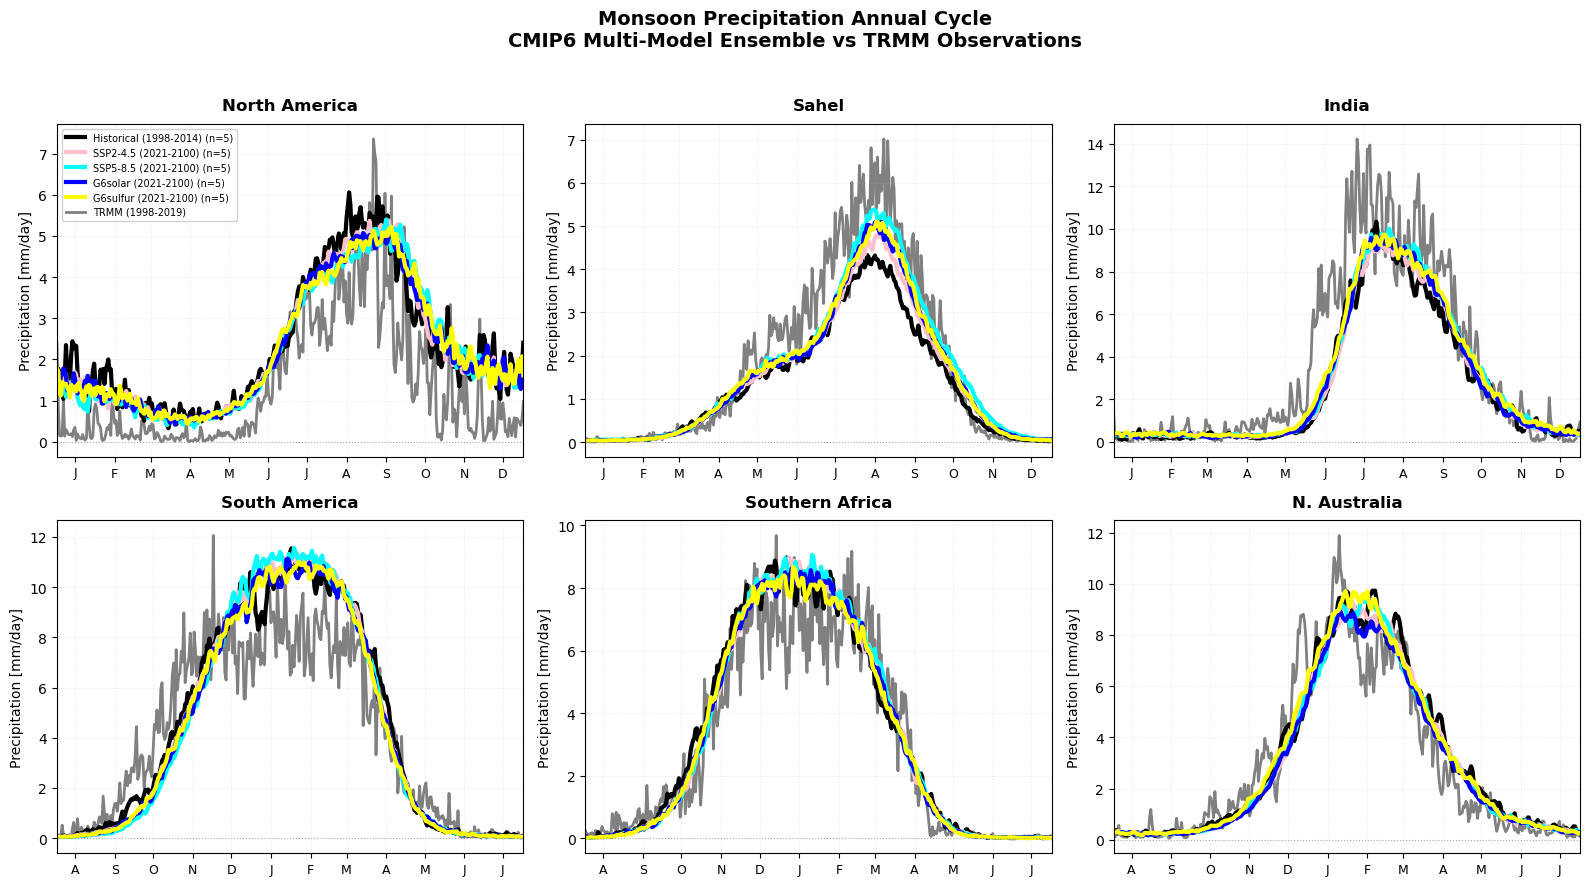

In [15]:
# Plot colors
# EXP_COLORS = {
#     "HIST": "gray",
#     "SSP245": "orange",
#     "SSP585": "red",
#     "G6solar": "blue",
#     "G6sulfur": "purple",
# }

EXP_COLORS = {
    "HIST": "black",
    "SSP245": "pink",
    "SSP585": "cyan",
    "G6solar": "blue",
    "G6sulfur": "yellow",
}

# ══════════════════════════════════════════════════════════════════════════════
# PLOTTING
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("GENERATING PLOTS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

doys = np.arange(1, N_DOY + 1)

for idx, (region, domain) in enumerate(DOMAINS.items()):
    ax = axes[idx]
    print(f"\n{region}:")
    
    start_doy = AUG1_DOY if region in SH_REGIONS else 1
    
    # Plot each experiment
    for exp, exp_meta in EXPERIMENTS.items():
        cycles = model_clim[region][exp]
        
        if len(cycles) == 0:
            continue
        
        print(f"  {exp}: {len(cycles)} models")
        
        cycles = np.array(cycles)
        mme_mean = np.nanmean(cycles, axis=0)
        mme_std = np.nanstd(cycles, axis=0)
        
        # Reindex for SH
        if start_doy != 1:
            mme_mean = reindex_cycle(mme_mean, start_doy)
            mme_std = reindex_cycle(mme_std, start_doy)
        
        ax.plot(doys, mme_mean,
               color=EXP_COLORS[exp],
               linewidth=3,
               label=f"{EXP_LABELS[exp]} (n={len(cycles)})")
        
        # ax.fill_between(doys,
        #                mme_mean - mme_std,
        #                mme_mean + mme_std,
        #                color=EXP_COLORS[exp],
        #                alpha=0.2)
    
    # TRMM overlay
    if trmm_clim[region] is not None:
        trmm_cycle = trmm_clim[region]
        if start_doy != 1:
            trmm_cycle = reindex_cycle(trmm_cycle, start_doy)
        
        ax.plot(doys, trmm_cycle,
               color='gray',
               linewidth=2,
               label=f'TRMM ({TRMM_YEAR_START}-{TRMM_YEAR_END})',
               zorder=-10)
    
    # Formatting
    ticks, labels = make_xticks(start_doy)
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, fontsize=9)
    
    ax.axhline(0, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
    ax.set_title(region, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel("Precipitation [mm/day]", fontsize=10)
    ax.set_xlim(1, N_DOY)
    ax.grid(True, alpha=0.25, linestyle=':')
    
    if idx == 0:
        ax.legend(fontsize=7, loc='upper left', framealpha=0.9)

plt.suptitle('Monsoon Precipitation Annual Cycle\n'
             'CMIP6 Multi-Model Ensemble vs TRMM Observations',
             fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])

outfile = OUTPUT_DIR / "rainfall_cycles_CMIP6_vs_TRMM_noSpread.png"
plt.savefig(outfile, dpi=200, bbox_inches='tight')
print(f"\n{'='*80}")
print(f"SAVED: {outfile}")
print(f"{'='*80}\n")

plt.show()